<a href="https://colab.research.google.com/github/hannaginther/ENGG680_2025_Fall/blob/Diya's-Branch/Project/Group_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ENGG680 - Introduction to Digital Engineering**
## *Group Project: Implementing ML model for Hospital Length of Stay Prediction*

## Preliminary: Certificate of Work
### (5 Marks)

*We, the undersigned, certify that this is our own work, which has been done expressly for this course, either without the assistance of any other party or where appropriate we have acknowledged the work of others. Further, we have read and understood the section in the university calendar on plagiarism/cheating/other academic misconduct and we are aware of the implications thereof. We request that the total mark for this assignment be distributed as follows among group members:*

|          | First Name | Last Name | Signature (Full Name, Date) | Hours | Contribution % |
|----------|------------|-----------|-----------------------------|-------|----------------|
| Member 1: | Allison | Haynes | Signature, Date | hrs | 33.33% |
| Member 2: | Diya | Chakraborty | Signature, Date | hrs | 33.33% |
| Member 3: | Hanna | Ginther | Signature, Date | hrs | 33.33% |


##**Step #1: Data Cleaning & Preprocessing:**

In [6]:
#TESTING FETCHING MAIN TO HANNA
print ('This is a test!')

This is a test!


##**Import Libraries and Load Datasets**

In [7]:
from google.colab import drive
drive.mount ('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

In [10]:
sparcs_2024 = pd.read_csv('/content/drive/MyDrive/Sparcs_Datafiles/Hospital_Inpatient_Discharges_(SPARCS_De-Identified)__2024_20251029.csv')

/tmp/ipython-input-841084618.py:1: DtypeWarning: Columns (29) have mixed types. Specify dtype option on import or set low_memory=False.
  sparcs_2024 = pd.read_csv('/content/drive/MyDrive/Sparcs_Datafiles/Hospital_Inpatient_Discharges_(SPARCS_De-Identified)__2024_20251029.csv')


In [11]:
sparcs_2023 = pd.read_csv('/content/drive/MyDrive/Sparcs_Datafiles/Hospital_Inpatient_Discharges_(SPARCS_De-Identified)__2023_20251029.csv')

/tmp/ipython-input-1854978552.py:1: DtypeWarning: Columns (29) have mixed types. Specify dtype option on import or set low_memory=False.
  sparcs_2023 = pd.read_csv('/content/drive/MyDrive/Sparcs_Datafiles/Hospital_Inpatient_Discharges_(SPARCS_De-Identified)__2023_20251029.csv')


##**Inspect Data Structure and Check Missing Values**

In [12]:
sparcs_2023.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2125754 entries, 0 to 2125753
Data columns (total 33 columns):
 #   Column                               Dtype  
---  ------                               -----  
 0   Hospital Service Area                object 
 1   Hospital County                      object 
 2   Operating Certificate Number         float64
 3   Permanent Facility Id                float64
 4   Facility Name                        object 
 5   Age Group                            object 
 6   Zip Code - 3 digits                  object 
 7   Gender                               object 
 8   Race                                 object 
 9   Ethnicity                            object 
 10  Length of Stay                       object 
 11  Type of Admission                    object 
 12  Patient Disposition                  object 
 13  Discharge Year                       int64  
 14  CCSR Diagnosis Code                  object 
 15  CCSR Diagnosis Description      

In [13]:
sparcs_2024.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2196737 entries, 0 to 2196736
Data columns (total 33 columns):
 #   Column                               Dtype  
---  ------                               -----  
 0   Health Service Area                  object 
 1   Hospital County                      object 
 2   Operating Certificate Number         float64
 3   Permanent Facility Id                float64
 4   Facility Name                        object 
 5   Age Group                            object 
 6   Zip Code                             object 
 7   Gender                               object 
 8   Race                                 object 
 9   Ethnicity                            object 
 10  Length of Stay                       object 
 11  Type of Admission                    object 
 12  Patient Disposition                  object 
 13  Discharge Year                       int64  
 14  CCSR Diagnosis Code                  object 
 15  CCSR Diagnosis Description      

In [14]:
sparcs_2023.head()

,Hospital Service Area,Hospital County,Operating Certificate Number,Permanent Facility Id,Facility Name,Age Group,Zip Code - 3 digits,Gender,Race,Ethnicity,...,APR Severity of Illness Description,APR Risk of Mortality,APR Medical Surgical Description,Payment Typology 1,Payment Typology 2,Payment Typology 3,Birth Weight,Emergency Department Indicator,Total Charges,Total Costs
0,New York City,Bronx,7000006.0,3058.0,Montefiore Med Center - Jack D Weiler Hosp of ...,50 to 69,104,F,Other Race,Spanish/Hispanic,...,Moderate,Moderate,Medical,Medicaid,NaN,NaN,NaN,Y,"27,380.60","3,533.21"
1,New York City,Bronx,7000006.0,1168.0,Montefiore Medical Center-Wakefield Hospital,30 to 49,104,M,Black/African American,Not Span/Hispanic,...,Moderate,Minor,Medical,Medicaid,NaN,NaN,NaN,Y,"82,629.98","12,715.35"
2,New York City,Bronx,7000006.0,3058.0,Montefiore Med Center - Jack D Weiler Hosp of ...,50 to 69,104,M,Other Race,Not Span/Hispanic,...,Extreme,Extreme,Medical,Medicare,Medicaid,NaN,NaN,Y,"76,210.47","11,201.40"
3,New York City,Bronx,7000006.0,1169.0,Montefiore Medical Center - Henry & Lucy Moses...,18 to 29,104,M,Black/African American,Not Span/Hispanic,...,Moderate,Minor,Medical,Medicaid,NaN,NaN,NaN,Y,"77,532.60","13,872.77"
4,New York City,Bronx,7000006.0,1169.0,Montefiore Medical Center - Henry & Lucy Moses...,50 to 69,104,F,Other Race,Spanish/Hispanic,...,Major,Moderate,Medical,Medicare,Medicaid,NaN,NaN,Y,"63,430.29","10,249.28"


In [15]:
sparcs_2024.head()

,Health Service Area,Hospital County,Operating Certificate Number,Permanent Facility Id,Facility Name,Age Group,Zip Code,Gender,Race,Ethnicity,...,APR Severity of Illness Description,APR Risk of Mortality,APR Medical Surgical Description,Payment Typology 1,Payment Typology 2,Payment Typology 3,Birth Weight,Emergency Department Indicator,Total Charges,Total Costs
0,Hudson Valley,Westchester,5957001.0,1139.0,WESTCHESTER MEDICAL CENTER,0-17,OOS,F,White,Not Span/Hispanic,...,Moderate,Minor,Medical,Private Health Insurance,NaN,NaN,NaN,Y,46814.00,6772.07
1,New York City,Queens,7003001.0,1628.0,FLUSHING HOSPITAL MEDICAL CENTER,0-17,113,M,White,Spanish/Hispanic,...,Moderate,Moderate,Medical,Medicaid,NaN,NaN,NaN,Y,13490.00,15464.30
2,New York City,New York,7002054.0,1458.0,NEW YORK-PRESBYTERIAN HOSPITAL - NEW YORK WEIL...,70 or Older,100,M,White,Not Span/Hispanic,...,Moderate,Moderate,Medical,Medicare,Private Health Insurance,NaN,NaN,Y,49503.16,9324.77
3,New York City,New York,7002054.0,1464.0,NEW YORK-PRESBYTERIAN HOSPITAL - COLUMBIA PRES...,0-17,100,F,Other Race,Not Span/Hispanic,...,Minor,Minor,Medical,Private Health Insurance,NaN,NaN,2700,Y,27827.66,7304.27
4,New York City,New York,7002032.0,1466.0,MOUNT SINAI WEST,18-29,100,F,Other Race,Spanish/Hispanic,...,Moderate,Minor,Medical,Medicare,NaN,NaN,NaN,Y,32798.29,7948.10


##**Dropping Unnecessary Columns, Matching 2023 Column Names to 2024, Changing Dtypes to Prep for Merging DataFrames**

In [16]:
# Drop hospital costs, emergency indicator, birth weight from both dataframes
sparcs_2023.drop(columns=['Total Costs', 'Emergency Department Indicator', 'Birth Weight', 'Operating Certificate Number'], inplace=True)
sparcs_2024.drop(columns=['Total Costs', 'Emergency Department Indicator', 'Birth Weight', 'Operating Certificate Number'], inplace=True)

In [17]:
# Change column names in sparcs_2023 to match 2024 DataFrame:
sparcs_2023.rename(columns={
    'Hospital Service Area':'Health Service Area',
    'Zip Code - 3 digits':'Zip Code'
}, inplace=True)

In [18]:
# Change dtype of charges column in sparcs_2023 to float64:
sparcs_2023['Total Charges'] = (sparcs_2023['Total Charges'].replace(',', '', regex=True).astype('float64'))

##**Compare Code/Description Columns and Facility ID/Name Columns to find matches between datasets**

In [19]:
# Identify code/description columns
code_cols = [
    'CCSR Diagnosis Code',
    'CCSR Procedure Code',
    'APR DRG Code',
    'APR MDC Code'
]

desc_cols = [
    'CCSR Diagnosis Description',
    'CCSR Procedure Description',
    'APR DRG Description',
    'APR MDC Description'
]

# Pair code/desc columns
code_columns = list(zip(code_cols, desc_cols))

# Normalize description columns in sparcs_2023
for _, desc_col in code_columns:
  if desc_col in sparcs_2023.columns:
    sparcs_2023[desc_col] = sparcs_2023[desc_col].apply(
        lambda x: x.upper().replace('&', 'AND') if isinstance(x, str) else x
        )

# Compare datasets
comparison_codes_results = {}
for code_col, desc_col in code_columns:
  df_2023 = sparcs_2023[[code_col, desc_col]].drop_duplicates()
  df_2024 = sparcs_2024[[code_col, desc_col]].drop_duplicates()

  merged = df_2023.merge(df_2024, on=code_col, how='outer', suffixes=('_2023', '_2024'))

  # Add indicator for where code appears
  merged['_status_'] = merged.apply(
      lambda row: (
          'Only in 2023' if pd.isna(row[desc_col + '_2024']) else
          'Only in 2024' if pd.isna(row[desc_col + '_2023']) else
          'Description mismatch' if row[desc_col + '_2023'] != row[desc_col + '_2024'] else
          'Match'
      ),
      axis=1
    )

  comparison_codes_results[code_col] = merged

# Combine comparisons
combined_codes_results = pd.concat(
    [df.assign(Column_Compared=col) for col, df in comparison_codes_results.items()],
    ignore_index=True
)

# Select columns that exist for code/desc
all_cols = ['Column_Compared', '_status_']
for code_col, desc_col in code_columns:
  for col in [code_col, desc_col + '_2023', desc_col + '_2024']:
    if col in combined_codes_results.columns:
      all_cols.append(col)

combined__codes_results = combined_codes_results[all_cols]

# Save to CSV
combined__codes_results.to_csv('/content/sparcs_codes_comparison.csv', index=False)
print("Comparison results saved to /content/sparcs_codes_comparison.csv")

Comparison results saved to /content/sparcs_codes_comparison.csv


In [20]:
# Get column info related to facility id/name
facility_id = ['Permanent Facility Id']
facility_name = ['Facility Name']

facility_columns = list(zip(facility_id, facility_name))

# Normalize facility column for sparcs_2023
for _, facility_name in facility_columns:
  if facility_name in sparcs_2023.columns:
    sparcs_2023[facility_name] = sparcs_2023[facility_name].apply(
        lambda x: x.upper() if isinstance(x, str) else x
    )
# Compare datasets
comparison_facility_results = {}
for facility_id, facility_name in facility_columns:
  df_2023 = sparcs_2023[[facility_id, facility_name]].drop_duplicates()
  df_2024 = sparcs_2024[[facility_id, facility_name]].drop_duplicates()

  merged = df_2023.merge(df_2024, on=facility_id, how='outer', suffixes=('_2023', '_2024'))

  merged['_status_'] = merged.apply(
      lambda row: (
          'Only in 2023' if pd.isna(row[facility_name + '_2024']) else
          'Only in 2024' if pd.isna(row[facility_name + '_2023']) else
          'Name mismatch' if row[facility_name + '_2023'] != row[facility_name + '_2024'] else
          'Match'
      ),
      axis=1
    )
  comparison_facility_results[facility_id] = merged

  # Combine comparisons
  combined_facility_results = pd.concat(
      [df.assign(Column_Compared=col) for col, df in comparison_facility_results.items()],
      ignore_index=True
  )

  # Select columns that exist for facility ID/Name
  all_facility_cols = ['Column_Compared', '_status_']
  for facility_id, facility_name in facility_columns:
    for col in [facility_id, facility_name + '_2023', facility_name + '_2024']:
      if col in combined_facility_results.columns:
        all_facility_cols.append(col)

  combined_facility_results = combined_facility_results[all_facility_cols]



##**Develop a Fuzzy Matching Function to Search for Similar, but Differently Reported Values**

In [21]:
!pip install rapidfuzz

In [22]:
# Normalize facility column capitalization for sparcs_2023
for facility_name in ['Facility Name']:
  if facility_name in sparcs_2023.columns:
    sparcs_2023[facility_name] = sparcs_2023[facility_name].apply(
        lambda x: x.upper() if isinstance(x, str) else x
    )

# Normalize CCSR Diagnosis Description capitalization for sparcds_2023
for ccsr_desc in ['CCSR Diagnosis Description']:
  if ccsr_desc in sparcs_2023:
    sparcs_2023[ccsr_desc] = sparcs_2023[ccsr_desc].apply(
        lambda x: x.upper() if isinstance(x, str) else x
    )

In [23]:
# Replace all uses of ampersand in sparcs_2023 with 'AND' except for facility name
for and_val in sparcs_2023:
  if and_val not in ['Facility Name']:
    sparcs_2023[and_val] = sparcs_2023[and_val].apply(
        lambda x: x.replace('&', 'AND') if isinstance(x, str) else x
    )

In [24]:
# Define a function to preprocess strings for fuzzy matching
# STEP 1: convert all object dtypes to strings except for specified columns
excluded_columns = ['Zip Code', 'Length of Stay', 'CCSR Diagnosis Code', 'CCSR Procedure Code']

# Get Object Columns except for excluded ones
convert_columns_2023 = [col for col in sparcs_2023.select_dtypes('object').columns if col not in excluded_columns]
convert_columns_2024 = [col for col in sparcs_2024.select_dtypes('object').columns if col not in excluded_columns]

sparcs_2023 = sparcs_2023.astype({col: 'string' for col in convert_columns_2023})
sparcs_2024 = sparcs_2024.astype({col: 'string' for col in convert_columns_2024})

# Convert selected object columns to string

# STEP 2: preprocessing function:
def clean_string(s):
  """
  Lowercase, remove punctuation, normalize whitespace.
  """
  if pd.isna(s):
    return(s)
  s = str(s).lower()                    # lowercase
  s = re.sub(r'[^\w\s]', '', s)         # remove punctuation
  s = re.sub(r'\s+', ' ', s)            # normalize whitespace
  return s.strip()

In [25]:
import re
from rapidfuzz import process, fuzz

# Def fuzzy matching function for all object columns:
def fuzzy_match_all_columns (df1, df2, object_columns, threshold=50, scorer=fuzz.ratio):
  """
  Perform a fuzzy matching function between df1 and df2 across all object/string columns

  Parameters
  ----------
  - df1, df2 : pd.DataFrame
      DataFrames to compare
  - object_columns : list
      Columns in DataFrame to compare (targets)
  - threshold : int, optional
      Minimum similarity score (0-100) for inclusion
  - scorer : function
      Fuzzy scoring function (default = fuzz.ratio)

  Returns
  -------
  pd.DataFrame
    DataFrame with matches and similarity scores >= threshold
  """

  # STEP 1: Identify
  all_matches = []
  for col in object_columns:
    print(f"Processing column: {col}")

    # Unique Values
    vals_2023 = df1[col].dropna().unique()
    vals_2024 = df2[col].dropna().unique()

    # Skip if either dataset has no values for this column
    if len(vals_2023) == 0 or len(vals_2024) == 0:
        print(f"  Skipping column '{col}' (no values to match)")
        continue

    # Call clean_string function to preprocess 2024 values
    preprocessed_2024 = {v: clean_string(v) for v in vals_2024}

    for v in vals_2023:
      clean_v = clean_string(v)
      best_match = process.extractOne(
          clean_v,
          preprocessed_2024.values(),
          scorer=scorer
      )
      if best_match:
        matched_val, score, _ = best_match
        if score >= threshold:
          # Recover original 2024 string:
          original_2024 = next(k for k, val in preprocessed_2024.items() if val == matched_val)
          all_matches.append({
              'Column': col,
              '2023_value': v,
              '2024_best_match': original_2024,
              'Similarity_Score': score
          })
  if all_matches:
        return pd.DataFrame(all_matches)
  else:
        print("No matches found above the threshold.")
        return pd.DataFrame(columns=['Column', '2023_value', '2024_best_match', 'Similarity_Score'])

  return pd.DataFrame(all_matches)

In [26]:
# Fuzzy Match function usage:
object_cols = [
    'Health Service Area',
    'Hospital County',
    'Facility Name',
    'Age Group',
    'Gender',
    'Race',
    'Ethnicity',
    'Type of Admission',
    'Patient Disposition',
    'CCSR Diagnosis Description',
    'CCSR Procedure Description',
    'APR DRG Description',
    'APR MDC Description',
    'APR Severity of Illness Description',
    'APR Risk of Mortality',
    'APR Medical Surgical Description',
    'Payment Typology 1',
    'Payment Typology 2',
    'Payment Typology 3'
]

# Run full fuzzy matching
all_matches_df = fuzzy_match_all_columns(
    sparcs_2023,
    sparcs_2024,
    object_cols,
    threshold=50,
)

Processing column: Health Service Area
Processing column: Hospital County
Processing column: Facility Name
Processing column: Age Group
Processing column: Gender
Processing column: Race
Processing column: Ethnicity
Processing column: Type of Admission
Processing column: Patient Disposition
Processing column: CCSR Diagnosis Description
Processing column: CCSR Procedure Description
Processing column: APR DRG Description
Processing column: APR MDC Description
Processing column: APR Severity of Illness Description
Processing column: APR Risk of Mortality
Processing column: APR Medical Surgical Description
Processing column: Payment Typology 1
Processing column: Payment Typology 2
Processing column: Payment Typology 3


In [27]:
all_matches_df.head()

,Column,2023_value,2024_best_match,Similarity_Score
0,Health Service Area,New York City,New York City,100.0
1,Health Service Area,Hudson Valley,Hudson Valley,100.0
2,Health Service Area,Western NY,Western NY,100.0
3,Health Service Area,Finger Lakes,Finger Lakes,100.0
4,Health Service Area,Central NY,Central NY,100.0


In [28]:
# Get CSV of fuzzy matches:
all_matches_df.to_csv('/content/sparcs_fuzzy_match_review.csv', index=False)

##**Create a Harmonization Function Before Combining Sparcs_2023 and 2024**

In [29]:
# Defining Harmonization Function to correct sparcs_2023 values

def harmonize_categorical(
    df_2023,
    fuzzy_matches_df,
    similarity_threshold=90,
    manual_2024_to_2023=None,
    protected_cols=None,
    protected_values=None):

  """
  Harmonize categorical columns in df_2023 using fuzzy match results with 2024 as reference.

  Parameters:
  - df_2023: DataFrame for 2023
  - fuzzy_matches_df: DataFrame with ['Column', '2023_value', '2024_best_match', 'Similarity_Score']
  - similarity_threshold: float, minimum similarity to apply automatic harmonization
  - manual_2024_to_2023: dict of dicts for 2024->2023 overrides, e.g.,
      {'Column1': {'2024_val': '2023_val'}}
  - protected_cols: list of columns to skip completely (won't be harmonized)
  - protected_values: list of values to skip completely (won't be harmonized)

  Returns:
  - Harmonized df_2023
  """

  if protected_cols is None:
    protected_cols = []

  # Initialize harmonized DataFrame
  df_harmonized = df_2023.copy()

  # Ensure similarity score is numeric
  fuzzy_matches_df['Similarity_Score'] = pd.to_numeric(
      fuzzy_matches_df['Similarity_Score'], errors='coerce'
      )

  # Step 1: Harmonize based on fuzzy matches above threshold
  for col in fuzzy_matches_df['Column'].unique():
    if col in protected_cols or col not in df_harmonized.columns:
      continue    # skip protected or missing cols

    col_matches = fuzzy_matches_df[
        (fuzzy_matches_df['Column'] == col)
        & (fuzzy_matches_df['Similarity_Score'] >= similarity_threshold)
    ]

    if col_matches.empty:
      continue  # skip if no matches above threshold

    mapping_dict = dict(zip(col_matches['2023_value'], col_matches['2024_best_match']))

    protected_vals = protected_values.get(col, [] if protected_values else [])

    # Apply mapping (Preserve NaN and protected values)
    df_harmonized[col] = df_harmonized[col].apply(
        lambda x: mapping_dict.get(x, x)
        if pd.notna(x) and x not in protected_values
        else x
    )

  # Step 2: Apply manual overrides (2024 -> 2023; values below threshold)
  if manual_2024_to_2023:
    for col, overrides in manual_2024_to_2023.items():
      if col in df_harmonized.columns:
        df_harmonized[col] = df_harmonized[col].apply(
            lambda x: overrides.get(x, x) if pd.notna(x) else x
            )

  return df_harmonized


In [30]:
# Harmonization function usage:
sparcs_2023_harmonized = harmonize_categorical(
    df_2023 = sparcs_2023,
    fuzzy_matches_df = all_matches_df,
    similarity_threshold = 90,
    manual_2024_to_2023 = {
    "APR MDC Description": {
        "INJURIES, POISONINGS & TOXIC EFFECTS OF DRUGS": "POISONINGS, TOXIC EFFECTS OTHER INJURIES AND OTHER COMPLICATIONS OF TREATMENT",
        "FACTORS INFLUENCING HLTH STAT & OTHR CONTACTS WITH HLTH SERVCS": "REHABILITATION AFTERCARE OTHER FACTORS INFLUENCING HEALTH STATUS AND OTHER HEALTH SERVICE CONTACTS"
    },
    "Age Group": {
        "0 to 17": "0-17",
        "18 to 29": "18-29",
        "30 to 49": "30-49",
        "50 to 69": "50-69"
    },
    "Facility Name": {
        "NYC Health + Hospitals/South Brooklyn Health": "SOUTH BROOKLYN HEALTH"
    },
    "APR DRG Description": {
        "OTHER EAR, NOSE, MOUTH AND THROAT PROCEDURES": "OTHER EAR, NOSE, MOUTH, THROAT, CRANIOFACIAL, AND NECK PROCEDURES"
    },
    "Health Service Area": {
        "Capital/Adirond": "Capital/Adirondacks"
    },
    "Hospital County": {
        "St Lawrence": "Saint Lawrence"
    }
},
    protected_cols = [
        "Length of Stay",
        "Zip Code",
        "Permanent Facility Id",
        "Race",
        "Ethnicity",
        "APR MDC Code",
        "APR Severity of Illness Code",
        "APR Severity of Illness Description",
        "APR Risk of Mortality",
        "APR Medical Surgical Description",
        "Payment Typology 1",
        "Payment Typology 2",
        "Payment Typology 3"
        ],
    protected_values = {
        "APR MDC Description": ["DISEASES AND DISORDERS OF BLOOD, BLOOD FORMING ORGANS, IMMUNOLOG DISORD"]
    }
)

In [31]:
# Get CSV of harmonized sparcs_2023
sparcs_2023_harmonized.to_csv('/content/sparcs_2023_harmonized.csv', index=False)

In [32]:
sparcs_2023_harmonized.head()

,Health Service Area,Hospital County,Permanent Facility Id,Facility Name,Age Group,Zip Code,Gender,Race,Ethnicity,Length of Stay,...,APR MDC Code,APR MDC Description,APR Severity of Illness Code,APR Severity of Illness Description,APR Risk of Mortality,APR Medical Surgical Description,Payment Typology 1,Payment Typology 2,Payment Typology 3,Total Charges
0,New York City,Bronx,3058.0,MONTEFIORE MED CENTER - JACK D WEILER HOSP OF ...,50-69,104,F,Other Race,Spanish/Hispanic,1,...,23,FACTORS INFLUENCING HLTH STAT AND OTHR CONTACT...,2,Moderate,Moderate,Medical,Medicaid,<NA>,<NA>,27380.60
1,New York City,Bronx,1168.0,MONTEFIORE MEDICAL CENTER-WAKEFIELD HOSPITAL,30-49,104,M,Black/African American,Not Span/Hispanic,4,...,4,DISEASES AND DISORDERS OF THE RESPIRATORY SYSTEM,2,Moderate,Minor,Medical,Medicaid,<NA>,<NA>,82629.98
2,New York City,Bronx,3058.0,MONTEFIORE MED CENTER - JACK D WEILER HOSP OF ...,50-69,104,M,Other Race,Not Span/Hispanic,4,...,18,"INFECTIOUS AND PARASITIC DISEASES, SYSTEMIC OR...",4,Extreme,Extreme,Medical,Medicare,Medicaid,<NA>,76210.47
3,New York City,Bronx,1169.0,MONTEFIORE MEDICAL CENTER - HENRY & LUCY MOSES...,18-29,104,M,Black/African American,Not Span/Hispanic,5,...,16,DISEASES AND DISORDERS OF BLOOD BLOOD FORMING ...,2,Moderate,Minor,Medical,Medicaid,<NA>,<NA>,77532.60
4,New York City,Bronx,1169.0,MONTEFIORE MEDICAL CENTER - HENRY & LUCY MOSES...,50-69,104,F,Other Race,Spanish/Hispanic,3,...,18,"INFECTIOUS AND PARASITIC DISEASES, SYSTEMIC OR...",3,Major,Moderate,Medical,Medicare,Medicaid,<NA>,63430.29


In [33]:
changed_cols = []
for col in sparcs_2023.columns:
  if not sparcs_2023[col].equals(sparcs_2023_harmonized[col]):
    changed_cols.append(col)

print("Columns modified during harmonization: ", changed_cols)

Columns modified during harmonization:  ['Health Service Area', 'Hospital County', 'Facility Name', 'Age Group', 'Gender', 'Type of Admission', 'Patient Disposition', 'CCSR Diagnosis Description', 'CCSR Procedure Description', 'APR DRG Description', 'APR MDC Description']


In [34]:
# Apply manual corrections to sparcs_2024 - These are values in the 2024 DataFrame that lacked commas or clarity, or were spelled incorrectly
manual_corrections = {
    "Facility Name": {
        "COHEN'S CHILDREN MEDICAL CENTER W/LIJ": "COHEN CHILDREN'S MEDICAL CENTER"
    },
    "CCSR Diagnosis Description": {
        "CORONAVIRUS DISEASE 2019 (COVID-19)": "COVID-19"
    },
    "APR MDC Code": {
        "DISEASES AND DISORDERS OF THE SKIN SUBCUTANEOUS TISSUE AND BREAST":
          "DISEASES AND DISORDERS OF THE SKIN, SUBCUTANEOUS TISSUE AND BREAST",
        "ENDOCRINE NUTRITIONAL AND METABOLIC DISEASES AND DISORDERS":
          "ENDOCRINE, NUTRITIONAL AND METABOLIC DISEASES AND DISORDERS",
        "DISEASES AND DISORDERS OF BLOOD BLOOD FORMING ORGANS AND IMMUNOLOG DISORD":
          "DISEASES AND DISORDERS OF BLOOD, BLOOD FORMING ORGANS AND IMMUNOLOG DISORD"
    }
}

# Create a harmonized copy of sparcs_2024 for merging:
sparcs_2024_harmonized = sparcs_2024.copy()

# Input corrections
for col, mapping in manual_corrections.items():
  sparcs_2024_harmonized[col] = sparcs_2024_harmonized[col].replace(mapping)

##**Combine sparcs_2023 and sparcs_2024 into One DataFrame**

In [35]:
# Keep track of source year from each DataFrame w/new column:
sparcs_2023_harmonized['Year'] = 2023
sparcs_2024_harmonized['Year'] = 2024

# Combine DataFrames
sparcs_combined = pd.concat(
    [sparcs_2023_harmonized, sparcs_2024_harmonized],
    axis=0,
    ignore_index=True
)

In [36]:
# Get CSV of combined dataframe
sparcs_combined.to_csv('/content/sparcs_combined.csv', index=False)

##**Preprocess Combined DataFrame**

In [37]:
# Load DataFrame
sparcs_combined = pd.read_csv('/content/drive/MyDrive/Sparcs_Datafiles/sparcs_combined.csv')

In [38]:
sparcs_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4322491 entries, 0 to 4322490
Data columns (total 30 columns):
 #   Column                               Dtype  
---  ------                               -----  
 0   Health Service Area                  object 
 1   Hospital County                      object 
 2   Permanent Facility Id                float64
 3   Facility Name                        object 
 4   Age Group                            object 
 5   Zip Code                             object 
 6   Gender                               object 
 7   Race                                 object 
 8   Ethnicity                            object 
 9   Length of Stay                       object 
 10  Type of Admission                    object 
 11  Patient Disposition                  object 
 12  Discharge Year                       int64  
 13  CCSR Diagnosis Code                  object 
 14  CCSR Diagnosis Description           object 
 15  CCSR Procedure Code             

In [39]:
# Convert any remaining string Dtypes in sparcs_combined to objects:
for col in sparcs_combined.select_dtypes('string').columns:
  sparcs_combined[col] = sparcs_combined[col].astype('object')

In [40]:
# Drop year column
sparcs_combined.drop(columns=['Year'], inplace=True)

In [41]:
# Convert permanent facility id to object
sparcs_combined['Permanent Facility Id'] = sparcs_combined['Permanent Facility Id'].astype('object')

# Convert APR codes to objects
for col in ['APR DRG Code', 'APR MDC Code', 'APR Severity of Illness Code']:
  sparcs_combined[col] = sparcs_combined[col].astype('object')

In [42]:
# Remove entries that are missing zip code values
sparcs_combined = sparcs_combined.dropna(subset=['Zip Code'])

In [43]:
# Save new CSV of cleaned sparcs combined
sparcs_combined.to_csv('/content/drive/MyDrive/Sparcs_Datafiles/sparcs_combined_clean_v1.csv', index=False)

In [44]:
# Create a function to create mapping dict for {Facility Id: Name, and all codes: descriptions}
import logging

# Set up basic logger
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')
logger = logging.getLogger(__name__)

def create_all_code_mappings (df, code_desc_pairs, excel_output_path=None):
  """
  Creates a mapping dictionary for multiple code-description pairs,
  drops all description columns,
  logs progress and optionally exports to excel (one sheet per code/desc pair).

  Parameters
  ----------
  - df: pd.DataFrame
        DataFrame with code and description columns.
  - code_desc_pairs: list of tuples
        List of (code_column, description_column) pairs.
  - excel_output_path: str, optional
        Path to save the output Excel file.
  Returns
  ----------
  - tuple
        (mapping_dicts, updated_df)
  """

  df = df.copy()
  mapping_dicts = {}

  def process_single_mapping (df, code_col, desc_col):
    logger.info(f"Processing mapping: {code_col} -> {desc_col}")

    # Filter out empty of invalid entries
    valid_rows = df[(df[code_col].notna()) & (df[desc_col].notna()) & (df[code_col] != '')]

    # Create mapping dict
    mapping_dict = (
        valid_rows[[code_col, desc_col]]
        .drop_duplicates(subset=[code_col])
        .set_index(code_col)[desc_col]
        .to_dict()
    )

    # Drop description column
    df = df.drop(columns=[desc_col])

    logger.info(f"Mapping created: {len(mapping_dict)} unique codes")
    return mapping_dict, df

  # Process all code/description pairs
  for code_col, desc_col in code_desc_pairs:
    mapping_dict, df = process_single_mapping(df, code_col, desc_col)
    mapping_dicts[code_col] = mapping_dict

  # Export to excel if wanted, with sheet groupings by category
  if excel_output_path:
    logger.info(f"Exporting all mappings to Excel: {excel_output_path}")

    with pd.ExcelWriter(excel_output_path) as writer:
      for code_col, mapping in mapping_dicts.items():
        sheet_name = code_col.replace('code', '').strip().title()[:30]
        mapping_df = pd.DataFrame(list(mapping.items()), columns=['Code', 'Description'])
        mapping_df.to_excel(writer, sheet_name=sheet_name, index=False)

    logger.info("Excel export completed successfully")


  return mapping_dicts, df


# Using mapping_dicts function:
code_desc_pairs = [
    ("Permanent Facility Id", "Facility Name"),
    ("CCSR Diagnosis Code", "CCSR Diagnosis Description"),
    ("CCSR Procedure Code", "CCSR Procedure Description"),
    ("APR DRG Code", "APR DRG Description"),
    ("APR MDC Code", "APR MDC Description"),
    ("APR Severity of Illness Code", "APR Severity of Illness Description")
]

mappings, clean_df = create_all_code_mappings(
    df=sparcs_combined,
    code_desc_pairs=code_desc_pairs,
    excel_output_path='/content/sparcs_mappings.xlsx'
)


In [45]:
sparcs_combined_clean_v1 = pd.read_csv('/content/drive/MyDrive/Sparcs_Datafiles/sparcs_combined_clean_v1.csv')

In [46]:
sparcs_combined_clean_v1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238636 entries, 0 to 4238635
Data columns (total 29 columns):
 #   Column                               Dtype  
---  ------                               -----  
 0   Health Service Area                  object 
 1   Hospital County                      object 
 2   Permanent Facility Id                float64
 3   Facility Name                        object 
 4   Age Group                            object 
 5   Zip Code                             object 
 6   Gender                               object 
 7   Race                                 object 
 8   Ethnicity                            object 
 9   Length of Stay                       object 
 10  Type of Admission                    object 
 11  Patient Disposition                  object 
 12  Discharge Year                       int64  
 13  CCSR Diagnosis Code                  object 
 14  CCSR Diagnosis Description           object 
 15  CCSR Procedure Code             

#**Change Reporting of Payment Typology Columns**

In [47]:
# Get all unique values reported in Payment typology columns
for col in ['Payment Typology 1', 'Payment Typology 2', 'Payment Typology 3']:
  print(f"Unique values in {col}:")
  print(sparcs_combined_clean_v1[col].dropna().unique())
  print("\n")

Unique values in Payment Typology 1:
['Medicaid' 'Medicare' 'Private Health Insurance' 'Self-Pay'
 'Blue Cross/Blue Shield' 'Miscellaneous/Other' 'Federal/State/Local/VA'
 'Department of Corrections' 'Managed Care, Unspecified']


Unique values in Payment Typology 2:
['Medicaid' 'Blue Cross/Blue Shield' 'Private Health Insurance'
 'Federal/State/Local/VA' 'Medicare' 'Self-Pay' 'Miscellaneous/Other'
 'Managed Care, Unspecified' 'Department of Corrections']


Unique values in Payment Typology 3:
['Medicaid' 'Federal/State/Local/VA' 'Self-Pay' 'Medicare'
 'Private Health Insurance' 'Blue Cross/Blue Shield'
 'Managed Care, Unspecified' 'Miscellaneous/Other'
 'Department of Corrections']




In [48]:
# Get value counts in payment typology columns
for col in ['Payment Typology 1', 'Payment Typology 2', 'Payment Typology 3']:
  print(f"Value Counts for {col}:")
  print(sparcs_combined_clean_v1[col].value_counts(dropna=False))
  print("\n")

Value Counts for Payment Typology 1:
Payment Typology 1
Medicare                     1775903
Medicaid                     1251502
Private Health Insurance      601530
Blue Cross/Blue Shield        403119
Self-Pay                       61229
Managed Care, Unspecified      57198
Miscellaneous/Other            44160
Federal/State/Local/VA         40935
Department of Corrections       2834
NaN                              226
Name: count, dtype: int64


Value Counts for Payment Typology 2:
Payment Typology 2
NaN                          2264587
Medicaid                      826762
Medicare                      333777
Private Health Insurance      297494
Self-Pay                      255811
Blue Cross/Blue Shield        212895
Federal/State/Local/VA         24850
Managed Care, Unspecified      11150
Miscellaneous/Other            11124
Department of Corrections        186
Name: count, dtype: int64


Value Counts for Payment Typology 3:
Payment Typology 3
NaN                          3723609

In [49]:
# Define a function to change payment typology columns to binary values
def encode_payment_typologies(df, save_path="sparcs_cleaned_v2.csv"):
  """
  Transform payment typology columns into binary indicator features and returns
  new dataframe, retaining the original.

  - Converts the three categorical payment typology columns
    ('Payment Typology 1', 'Payment Typology 2', 'Payment Typology 3')
    into a set of binary columns.
  - Adds a numerical feature showing how many payers are present per row.
  - Deletes the original columns.
  - Saves a new cleaned dataframe to a CSV file.

  Parameters:
  - df: pd.DataFrame
      Input DataFrame with payment typology columns.

  - save_path: str, optional (default = "sparcs_cleaned_v2.csv")
      Path to save the new cleaned DataFrame.

  Returns:
  - df_cleaned: pd.DataFrame
      DataFrame with binary payer columns and a 'num_payers' feature and
      original columns dropped.

  """

  # Create a copy df so original is unchanged
  df_cleaned = df.copy()

  # Identify payment typology columns
  payment_cols = ['Payment Typology 1', 'Payment Typology 2', 'Payment Typology 3']

  # Get all unique payer types across all three columns
  unique_payers = pd.concat([df_cleaned[col] for col in payment_cols]).dropna().unique()

  # Create binary indicator for each unique payer type
  for payer in unique_payers:
    # Mark 1 if payer appears in any of the three payment typology columns, else mark 0
    df_cleaned[payer] = df_cleaned[payment_cols].eq(payer).any(axis=1).astype(int)

  # Add a feature counting how many payment typology fields are filled
  df_cleaned['Number of Payment Typologies'] = df_cleaned[payment_cols].notna().sum(axis=1)

  # Drop the original payment typology columns
  df_cleaned = df_cleaned.drop(columns=payment_cols)

  # Save the cleaned Dataframe as CSV
  df_cleaned.to_csv(save_path, index=False)

  return df_cleaned

In [50]:
# Payment typology function usage
sparcs_cleaned_v2 = encode_payment_typologies(
    df=sparcs_combined_clean_v1)

In [51]:
print(sparcs_cleaned_v2.columns)

Index(['Health Service Area', 'Hospital County', 'Permanent Facility Id',
       'Facility Name', 'Age Group', 'Zip Code', 'Gender', 'Race', 'Ethnicity',
       'Length of Stay', 'Type of Admission', 'Patient Disposition',
       'Discharge Year', 'CCSR Diagnosis Code', 'CCSR Diagnosis Description',
       'CCSR Procedure Code', 'CCSR Procedure Description', 'APR DRG Code',
       'APR DRG Description', 'APR MDC Code', 'APR MDC Description',
       'APR Severity of Illness Code', 'APR Severity of Illness Description',
       'APR Risk of Mortality', 'APR Medical Surgical Description',
       'Total Charges', 'Medicaid', 'Medicare', 'Private Health Insurance',
       'Self-Pay', 'Blue Cross/Blue Shield', 'Miscellaneous/Other',
       'Federal/State/Local/VA', 'Department of Corrections',
       'Managed Care, Unspecified', 'Number of Payment Typologies'],
      dtype='object')


In [52]:
sparcs_cleaned_v2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238636 entries, 0 to 4238635
Data columns (total 36 columns):
 #   Column                               Dtype  
---  ------                               -----  
 0   Health Service Area                  object 
 1   Hospital County                      object 
 2   Permanent Facility Id                float64
 3   Facility Name                        object 
 4   Age Group                            object 
 5   Zip Code                             object 
 6   Gender                               object 
 7   Race                                 object 
 8   Ethnicity                            object 
 9   Length of Stay                       object 
 10  Type of Admission                    object 
 11  Patient Disposition                  object 
 12  Discharge Year                       int64  
 13  CCSR Diagnosis Code                  object 
 14  CCSR Diagnosis Description           object 
 15  CCSR Procedure Code             

In [53]:
# Convert dtypes to ensure feature represented appropriately:
# Facility Id float -> object
sparcs_cleaned_v2['Permanent Facility Id'] = sparcs_cleaned_v2['Permanent Facility Id'].astype('object')

# Convert APR codes int64 -> object
for col in ['APR DRG Code', 'APR MDC Code', 'APR Severity of Illness Code']:
  sparcs_cleaned_v2[col] = sparcs_cleaned_v2[col].astype('object')

In [1]:
# Save changes to sparcs_cleaned_v2 as new CSV: sparcs_cleaned_v3
sparcs_cleaned_v2.to_csv('/content/drive/MyDrive/Sparcs_Datafiles/sparcs_cleaned_v3.csv', index=False)

NameError: name 'sparcs_cleaned_v2' is not defined

#**Handle Missing Values, Create Mapping dictionary for Code/Descriptions and Facility Id/Facility Name**

In [2]:
import pandas as pd

sparcs_cleaned_v3 = pd.read_csv('/content/drive/MyDrive/Sparcs_Datafiles/sparcs_cleaned_v3.csv')
#Check for missing values, the % missing and display as a table
missing_data = []
for col in sparcs_cleaned_v3.columns:
  missing_values = sparcs_cleaned_v3[col].isnull().sum()
  missing_percent = (missing_values / len(sparcs_cleaned_v3) * 100).round(2)
  missing_data.append({'Column': col, 'Missing Values': missing_values, 'Missing %': missing_percent})

missing_table = pd.DataFrame(missing_data)
display(missing_table)

,Column,Missing Values,Missing %
0,Health Service Area,0,0.00
1,Hospital County,0,0.00
2,Permanent Facility Id,0,0.00
3,Facility Name,0,0.00
4,Age Group,0,0.00
5,Zip Code,0,0.00
6,Gender,0,0.00
7,Race,0,0.00
8,Ethnicity,0,0.00
9,Length of Stay,0,0.00


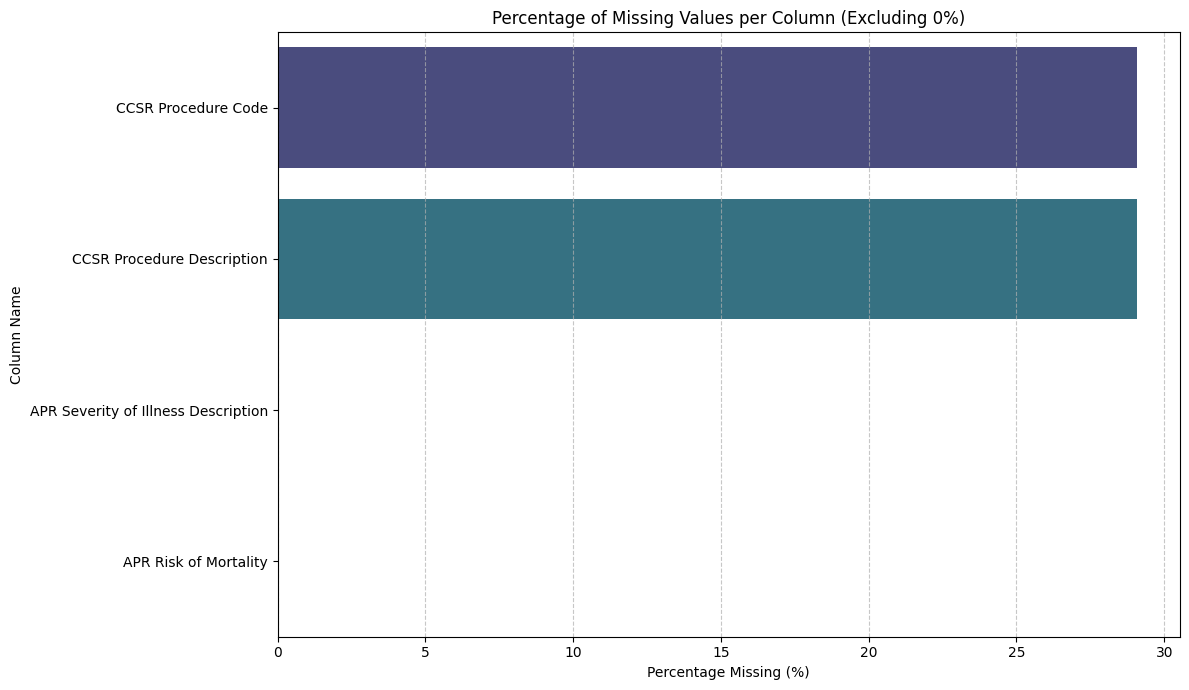

In [4]:
#Visualize Missing Data
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for columns with actual missing data
missing_table_filtered = missing_table[missing_table['Missing %'] > 0]

if not missing_table_filtered.empty:
    # Sort values for better visualization
    missing_table_filtered = missing_table_filtered.sort_values(by='Missing %', ascending=False)

    # Generate a bar chart visualizing these missing percentages
    plt.figure(figsize=(12, 7))
    sns.barplot(x='Missing %', y='Column', data=missing_table_filtered, palette='viridis', hue='Column', legend=False)
    plt.title('Percentage of Missing Values per Column (Excluding 0%)')
    plt.xlabel('Percentage Missing (%)')
    plt.ylabel('Column Name')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("No columns with missing values to display.")
#CCSR Procedure Code and CCSR Procedure Description both have a significant percentage of missing values, approximately 29.08%. This suggests that for a considerable portion of the records, a procedure code or description was not recorded.
#APR Severity of Illness Description and APR Risk of Mortality have a very small percentage of missing values, both around 0.01%. This indicates that these columns are almost complete, with only a handful of entries lacking this information.

#Statistical Summary and Visualizing Outliers

In [5]:
#Numeric and Category Outlier Checks
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

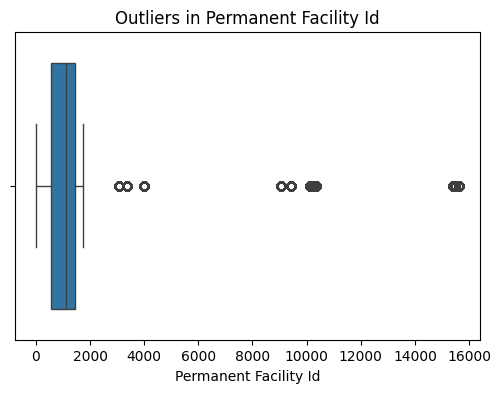

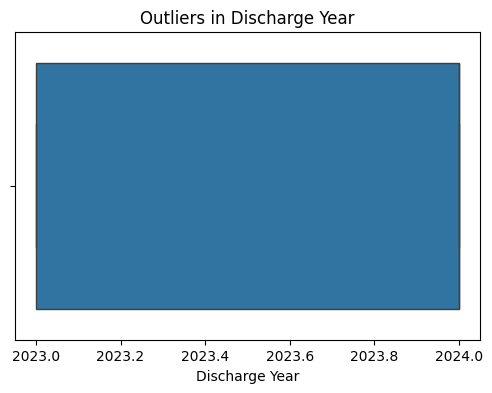

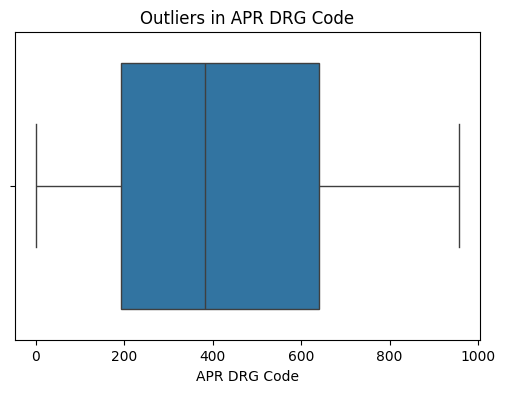

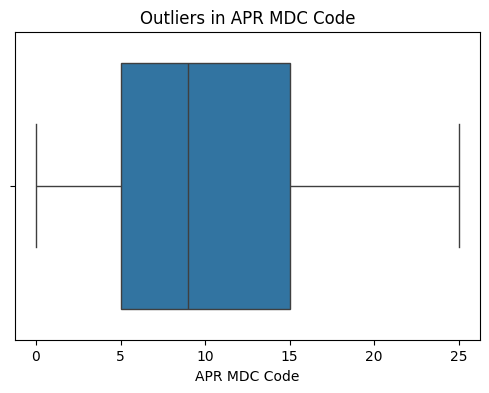

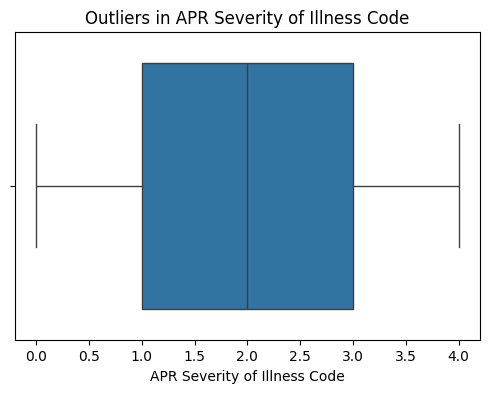

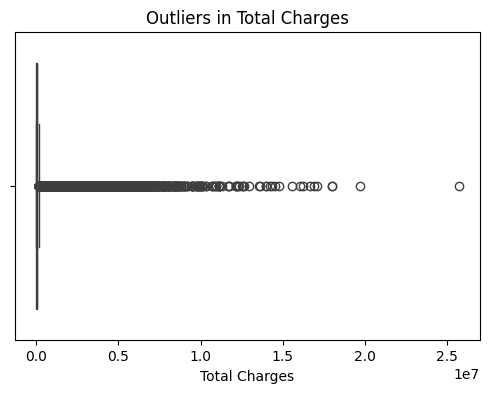

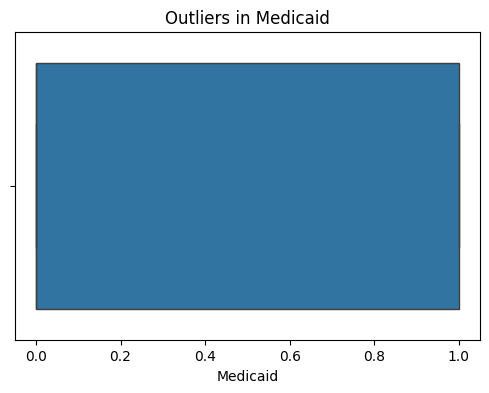

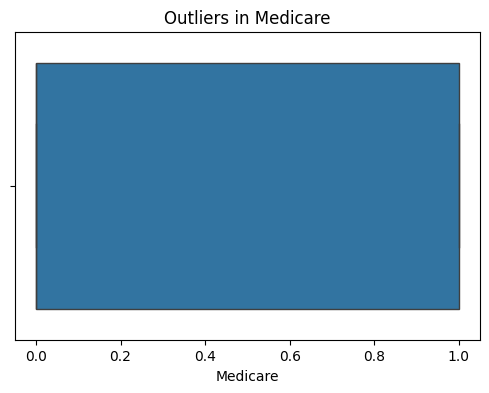

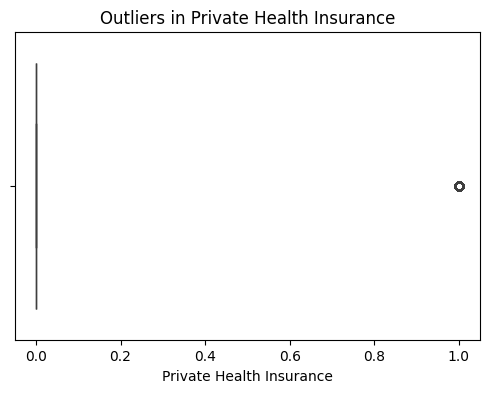

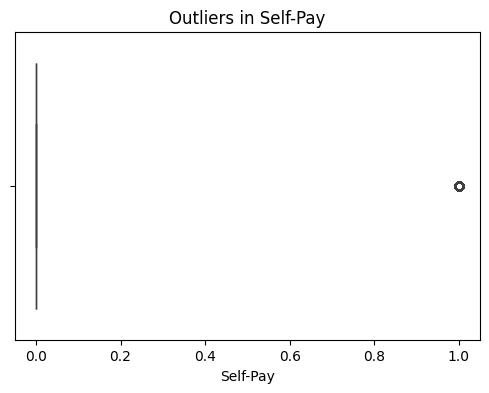

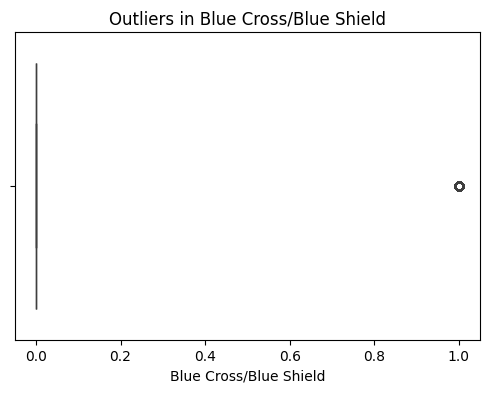

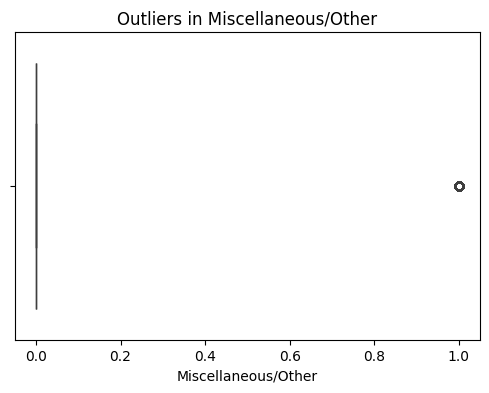

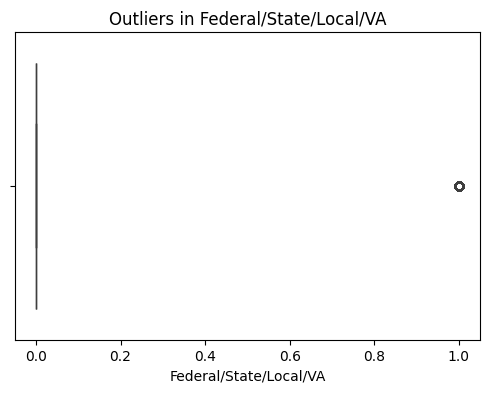

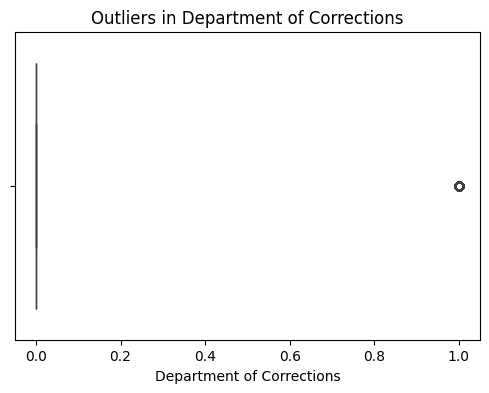

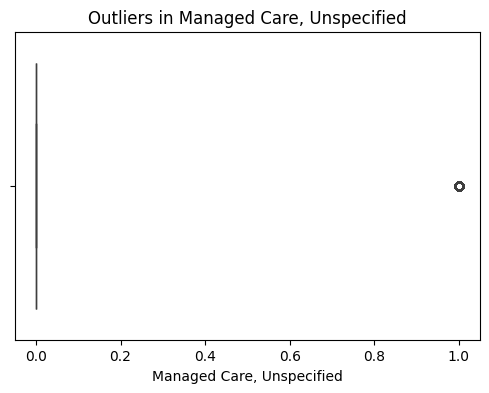

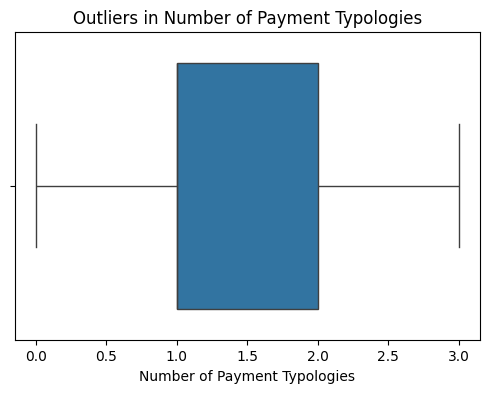

IQR Outlier Summary:
Permanent Facility Id: 208471 outliers (4.92%)
Discharge Year: 0 outliers (0.00%)
APR DRG Code: 0 outliers (0.00%)
APR MDC Code: 0 outliers (0.00%)
APR Severity of Illness Code: 0 outliers (0.00%)
Total Charges: 378694 outliers (8.93%)
Medicaid: 0 outliers (0.00%)
Medicare: 0 outliers (0.00%)
Private Health Insurance: 921016 outliers (21.73%)
Self-Pay: 574791 outliers (13.56%)
Blue Cross/Blue Shield: 634883 outliers (14.98%)
Miscellaneous/Other: 55276 outliers (1.30%)
Federal/State/Local/VA: 69452 outliers (1.64%)
Department of Corrections: 3052 outliers (0.07%)
Managed Care, Unspecified: 69078 outliers (1.63%)
Number of Payment Typologies: 0 outliers (0.00%)


In [9]:
#Numeric Outliers
numeric_cols = sparcs_cleaned_v3.select_dtypes(include=['float64', 'int64']).columns

#Boxplot Overview for Numeric Features
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=sparcs_cleaned_v3[col])
    plt.title(f'Outliers in {col}')
    plt.show()

#IQR Based Outlier Counts
def iqr_outlier_bounds(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return lower, upper

print("IQR Outlier Summary:")
for col in numeric_cols:
    lower, upper = iqr_outlier_bounds(sparcs_cleaned_v3, col)
    outliers = ((sparcs_cleaned_v3[col] < lower) | (sparcs_cleaned_v3[col] > upper)).sum()
    pct = (outliers / len(sparcs_cleaned_v3)) * 100
    print(f"{col}: {outliers} outliers ({pct:.2f}%)")

IQR analysis identified outliers in Total Charges (8.93%) and several one-hot encoded payment columns. Since payment columns are binary, outlier detection was not applicable. Total Charges were right-skewed with valid high-cost cases; therefore, a log transformation will be applied before modeling. Facility ID was identified as a non-predictive numeric identifier and will be excluded.

In [12]:
#Creating Log Transformed Column for "Total Charges" to Reduce Skew when Modelling
import numpy as np

sparcs_cleaned_v3['Log_Total_Charges'] = np.log1p(sparcs_cleaned_v3['Total Charges'])

#Verifying that the Transformation Worked

print("Skew before:", sparcs_cleaned_v3['Total Charges'].skew().round(2))
print("Skew after :", sparcs_cleaned_v3['Log_Total_Charges'].skew().round(2))

Skew before: 17.33
Skew after : 0.1


In [13]:
# Save updated dataset
sparcs_cleaned_v3.to_csv('sparcs_cleaned_v3_log.csv', index=False)

In [16]:
#Categorical Data Quality Check
import seaborn as sns
import matplotlib.pyplot as plt

# Identify categorical columns
categorical_cols = sparcs_cleaned_v3.select_dtypes(include=['object']).columns
print("Categorical Columns:", list(categorical_cols))

#Frequency counts for all categorical columns to show distribution and spot rare cases
for col in categorical_cols:
    print(f"\n{col} value counts (%):")
    print((sparcs_cleaned_v3[col].value_counts(normalize=True) * 100).round(2))
    print("-" * 40)

Categorical Columns: ['Health Service Area', 'Hospital County', 'Facility Name', 'Age Group', 'Zip Code', 'Gender', 'Race', 'Ethnicity', 'Length of Stay', 'Type of Admission', 'Patient Disposition', 'CCSR Diagnosis Code', 'CCSR Diagnosis Description', 'CCSR Procedure Code', 'CCSR Procedure Description', 'APR DRG Description', 'APR MDC Description', 'APR Severity of Illness Description', 'APR Risk of Mortality', 'APR Medical Surgical Description']

Health Service Area value counts (%):
Health Service Area
New York City          45.30
Long Island            16.48
Hudson Valley          11.12
Western NY              6.55
Capital/Adirondacks     6.51
Finger Lakes            6.48
Central NY              6.31
Southern Tier           1.25
Name: proportion, dtype: float64
----------------------------------------

Hospital County value counts (%):
Hospital County
Kings             9.11
New York          8.96
Nassau            8.83
Manhattan         8.68
Queens            8.54
Suffolk           

| Column                                  | Notes & ML Prep Actions                                                                                                                                                                                                                                                                           |
| --------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Health Service Area**                 | ✅ Nicely distributed (no category <1%).<br>Good regional feature — keep as categorical.                                                                                                                                                                                                           |
| **Hospital County**                     | ⚠️ Many low-frequency counties (<1%).<br>Group small ones (e.g., `<1%` into “Other County”) using `merge_rare_categories()`.<br>This will avoid hundreds of tiny dummy variables.                                                                                                                 |
| **Facility Name**                       | 🚫 Too many unique values (209 hospitals).<br>→ **High-cardinality categorical**: drop for basic ML, or later group by region or county if you want hospital-level effects.                                                                                                                       |
| **Age Group**                           | ✅ Clean, ordinal-like feature.<br>You can keep as categorical or map to ordered numbers (`0-17`=1, `18-29`=2, etc.) if model prefers numeric order.                                                                                                                                               |
| **Zip Code**                            | 🚫 High cardinality (lots of unique codes).<br>Either drop or group by first 3 digits (regional grouping). Otherwise, one-hot encoding will explode feature count.                                                                                                                                |
| **Gender**                              | ✅ Clean and balanced (M/F).<br>`U` = 0.01% → merge into “Unknown” or drop.                                                                                                                                                                                                                        |
| **Race**                                | ✅ Mostly fine.<br>“Multi-racial” = 1.32% → keep or merge with “Other Race”.                                                                                                                                                                                                                       |
| **Ethnicity**                           | ⚠️ “Multi-ethnic” = 0.16% → merge with “Unknown” or “Other”.<br>Keep otherwise — it’s an important SDOH variable.                                                                                                                                                                                 |
| **Length of Stay**                      | 🚫 This should **not** be categorical — it’s your **target variable** (numeric).<br>It’s only showing here because it’s stored as string or object.<br>Convert it back to numeric:<br>`sparcs_cleaned_v3['Length of Stay'] = pd.to_numeric(sparcs_cleaned_v3['Length of Stay'], errors='coerce')` |
| **Type of Admission**                   | ✅ Great distribution.<br>“Trauma” and “Not Available” are small but meaningful — keep as-is (don’t merge).                                                                                                                                                                                        |
| **Patient Disposition**                 | ⚠️ Long tail with many small groups (<1%).<br>Merge all categories under ~0.5% into “Other Disposition”.<br>This reduces noise and model sparsity.                                                                                                                                                |
| **CCSR Diagnosis Code / Description**   | 🚫 479 unique categories — extremely high cardinality.<br>Drop for initial model or group into broader “APR MDC” or “APR DRG” codes.<br>Including them directly will overfit.                                                                                                                     |
| **CCSR Procedure Code / Description**   | 🚫 Same issue — 319 unique categories.<br>Drop or group into “procedure family” level (if available).                                                                                                                                                                                             |
| **APR DRG Description**                 | 🚫 331 categories → too detailed for ML.<br>Better to use **APR MDC Description** instead (it’s higher-level).                                                                                                                                                                                    |
| **APR MDC Description**                 | ✅ Excellent summary feature (only ~25 categories).<br>Keep — it’s meaningful and not too granular.                                                                                                                                                                                                |
| **APR Severity of Illness Description** | ✅ Strong feature — ordinal categories (“Minor”→“Extreme”).<br>You can map to numeric scale 1–4 later.                                                                                                                                                                                             |
| **APR Risk of Mortality**               | ✅ Same as above — ordinal.<br>Map to 1–4 numeric scale for regression-type models.                                                                                                                                                                                                                |
| **APR Medical Surgical Description**    | ✅ Clean and simple (Medical/Surgical).<br>Keep as binary categorical (you can one-hot encode).                                                                                                                                                                                                    |



In [15]:
#DO NOT CODE YET THIS IS JUST WHAT I THINK THE CATEGORICAL OUTLIER CLEAN UP SHOULD LOOK LIKE BUT IM NOT SURE
#i made the code wrong so it wont work if u run all just in case :D (missing closing brackets)
#if you guys agree this looks good then go ahead and run it :) i will make us a clean ML ready csv file including all of these changes

# Convert LOS back to numeric (it shouldn't be categorical)
sparcs_cleaned_v3['Length of Stay'] = pd.to_numeric(sparcs_cleaned_v3['Length of Stay'], errors='coerce')

# Merge rare categories
sparcs_cleaned_v3 = merge_rare_categories(sparcs_cleaned_v3, 'Hospital County', threshold=0.01)
sparcs_cleaned_v3 = merge_rare_categories(sparcs_cleaned_v3, 'Patient Disposition', threshold=0.005)
sparcs_cleaned_v3['Ethnicity'] = sparcs_cleaned_v3['Ethnicity'].replace({'Multi-ethnic': 'Other'})
sparcs_cleaned_v3['Race'] = sparcs_cleaned_v3['Race'].replace({'Multi-racial': 'Other Race'})
sparcs_cleaned_v3['Gender'] = sparcs_cleaned_v3['Gender'].replace({'U': 'Unknown'})

# Drop high-cardinality columns for now (you can revisit later if you plan embeddings or NLP)
parcs_cleaned_v3 = sparcs_cleaned_v3.drop(columns=[
    'Facility Name',
    'Zip Code',
    'CCSR Diagnosis Code', 'CCSR Diagnosis Description',
    'CCSR Procedure Code', 'CCSR Procedure Description',
    'APR DRG Description'

SyntaxError: incomplete input (ipython-input-1199677558.py, line 20)

#Correlation Analysis

## Insights and Next Steps for Missing Values

### Insights from the Missing Data Visualization:
The bar chart clearly highlights the columns with missing data:
*   **CCSR Procedure Code** and **CCSR Procedure Description** both have a significant percentage of missing values, approximately 29.08%. This suggests that for a considerable portion of the records, a procedure code or description was not recorded.
*   **APR Severity of Illness Description** and **APR Risk of Mortality** have a very small percentage of missing values, both around 0.01%. This indicates that these columns are almost complete, with only a handful of entries lacking this information.

### Suggested Next Steps for Handling Missing Values:
1.  **CCSR Procedure Code and Description (29.08% missing):**
    *   **Investigation**: Understand *why* these values are missing. Is it a data entry issue, or do some patient encounters genuinely not involve a recorded procedure? This context is crucial.
    *   **Imputation**: Given the high percentage, simple imputation methods (e.g., mode) might introduce bias. If the missingness is truly random and independent of other variables, advanced imputation techniques (e.g., K-Nearest Neighbors, MICE) could be considered if the missing data mechanism is 'Missing At Random' (MAR). However, if procedures are genuinely absent, imputing them might be inappropriate.
    *   **Categorization**: Consider creating a new category like 'No Procedure Recorded' for these missing entries if it aligns with the domain knowledge and the nature of the data.
    *   **Feature Engineering**: If the absence of a procedure is meaningful, a binary indicator variable ('Has Procedure' / 'No Procedure') could be created.
    *   **Analysis without**: For certain analyses, it might be acceptable to simply exclude records with missing procedure codes, especially if the focus is on patients who *did* undergo procedures.

2.  **APR Severity of Illness Description and APR Risk of Mortality (0.01% missing):**
    *   **Investigation**: Due to the very small number of missing values, it's worth investigating these specific records. It could be a simple data entry error or an anomaly.
    *   **Deletion**: Given the extremely low percentage (463 records out of over 4 million), it is generally safe to remove these rows without significantly impacting the dataset or introducing bias. This is often the most straightforward approach for very few missing values.
    *   **Imputation**: Alternatively, for such a small number, imputation with the mode or a simple predictive model could be considered, but is likely an over-complication given the deletion option.

## Summary:

### Data Analysis Key Findings
*   The `sparcs_cleaned_v3` DataFrame was reloaded, and missing value percentages were calculated for all columns.
*   Two pairs of columns were identified with missing data:
    *   `CCSR Procedure Code` and `CCSR Procedure Description` both show a significant missing percentage of approximately 29.08% (1,232,780 records out of 4,239,836).
    *   `APR Severity of Illness Description` and `APR Risk of Mortality` both have a very small missing percentage of approximately 0.01% (463 records out of 4,239,836).
*   All other columns in the dataset were found to have no missing values (0%).
*   A bar chart visualizing these missing percentages confirmed that only these four columns contain missing data, with the procedure-related columns standing out prominently due to their high missing rates.

### Insights or Next Steps
*   **For CCSR Procedure Code and Description (29.08% missing):** Due to the high percentage of missing values, it is crucial to investigate the underlying reasons for their absence (e.g., data entry issues, or genuine lack of recorded procedures). Depending on the cause, strategies could include advanced imputation techniques (if data is Missing At Random), creating a 'No Procedure Recorded' category, or using a binary indicator for the presence/absence of a procedure.
*   **For APR Severity of Illness Description and APR Risk of Mortality (0.01% missing):** Given the extremely low number of missing values, the most pragmatic approach is to investigate these specific records to understand if they are anomalies or data entry errors. Subsequently, deleting these few rows is generally acceptable as it will not significantly impact the dataset's integrity or introduce bias.
